# Training Script for LSTM PyTorch One-Day Forecaster

## Settings and Imports

In [1]:
import os

import torch
import torch.optim as optim
import torch.nn as nn

import numpy as np

from utils.data_preparation import (
    prepare_data_for_modeling,
    prepare_lstm_loaders_with_target_scaling,
)
from utils.lstm_model import LSTMForecaster

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = os.path.join("models", "best_lstm_load_forecaster.pt")

REPROCESS_DATA = False
# Default date ranges for training, validation, and testing. 
TRAIN_START_DATE = "2020-01-01"
TRAIN_END_DATE = "2023-12-31"
VALIDATION_START_DATE = "2024-01-01"
VALIDATION_END_DATE = "2024-12-31"
TEST_START_DATE = "2025-01-01"
TEST_END_DATE = "2025-12-31"

TRAINING = True  # Set to True to train the model
TEST = True  # Set to True to evaluate the model on the test set
BATCH_SIZE = 32
EPOCHS = 3000
LEARNING_RATE = 5e-4
WINDOW_SIZE = 21  # Number of days to look back for the LSTM model
VALIDATE_EVERY = 10
EARLY_STOPPING_PATIENCE = 20
MIN_IMPROVEMENT = 1e-4

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# This features describe the today's weather and load.
# Features NOT included:
# - lag and std features, because they are derived from the load feature by the model
# - weather features with low importance according to the XGBoost feature importance plot (e.g. cloud cover, sunshine duration, wind speed, heating/cooling degrees)
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'load']

# These features describe the features of the next day (e.g. holiday and cyclic calendar terms).
FEATURES_TARGET_TIME = ['is_holiday', 'dow_sin',
                        'dow_cos', 'month_sin', 'month_cos']

FEATURES = FEATURES_TODAY + FEATURES_TARGET_TIME

# We will predict the load of the next day
TARGET = "load_t+1"

SCALE_FEATURES = FEATURES_TODAY

Using device: mps


## Dataset Loading and Preparation

In [2]:
data_dict, _ = prepare_data_for_modeling(
    FEATURES, TARGET, SCALE_FEATURES, save_scaler=True, save_data=True,
    train_start_date=TRAIN_START_DATE, train_end_date=TRAIN_END_DATE,
    val_start_date=VALIDATION_START_DATE, val_end_date=VALIDATION_END_DATE,
    test_start_date=TEST_START_DATE, test_end_date=TEST_END_DATE,
    reprocess_data=REPROCESS_DATA,
    production_data=False
)

prepared_data = prepare_lstm_loaders_with_target_scaling(
    data_dict=data_dict,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    training=TRAINING,
    test=TEST,
)

y_train_raw = prepared_data["y_train_raw"]
y_val_raw = prepared_data["y_val_raw"]
y_test_raw = prepared_data["y_test_raw"]

y_train = prepared_data["y_train"]
y_val = prepared_data["y_val"]
y_test = prepared_data["y_test"]

target_mean = prepared_data["target_mean"]
target_std = prepared_data["target_std"]

if TRAINING:
    training_loader = prepared_data["training_loader"]
    validation_loader = prepared_data["validation_loader"]

if TEST:
    test_loader = prepared_data["test_loader"]
    test_df = prepared_data["test_df"]  # For the timestamps

Target scaling -> mean: 55062.94, std: 6711.30


## Training Setup

In [3]:
model = LSTMForecaster(input_size=len(FEATURES),
                       hidden_size=64, num_layers=1, output_size=1, dropout=0.0).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.SmoothL1Loss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    threshold=MIN_IMPROVEMENT,
    threshold_mode="abs",
)

## Training

In [4]:
if TRAINING:
    best_val_mse = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        model.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        train_samples = 0

        for X_batch, y_batch in training_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            y_pred = model(X_batch).squeeze(-1)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = y_batch.size(0)
            train_samples += batch_size
            train_mse_sum += torch.sum((y_pred - y_batch) ** 2).item()
            train_mae_sum += torch.sum(torch.abs(y_pred - y_batch)).item()

        if epoch % VALIDATE_EVERY != 0:
            continue

        model.eval()
        val_mse_sum = 0.0
        val_mae_sum = 0.0
        val_samples = 0
        val_pred_sum = 0.0
        val_pred_sq_sum = 0.0

        with torch.no_grad():
            for X_batch, y_batch in validation_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_pred = model(X_batch).squeeze(-1)

                batch_size = y_batch.size(0)
                val_samples += batch_size
                val_mse_sum += torch.sum((y_pred - y_batch) ** 2).item()
                val_mae_sum += torch.sum(torch.abs(y_pred - y_batch)).item()
                val_pred_sum += torch.sum(y_pred).item()
                val_pred_sq_sum += torch.sum(y_pred ** 2).item()

        train_mse = train_mse_sum / train_samples
        train_rmse = np.sqrt(train_mse)
        train_mae = train_mae_sum / train_samples
        val_mse = val_mse_sum / val_samples
        val_rmse = np.sqrt(val_mse)
        val_mae = val_mae_sum / val_samples

        val_pred_mean = val_pred_sum / val_samples
        val_pred_var = max((val_pred_sq_sum / val_samples) -
                           (val_pred_mean ** 2), 0.0)
        val_pred_std = np.sqrt(val_pred_var)

        scheduler.step(val_mse)

        improved = val_mse < (best_val_mse - MIN_IMPROVEMENT)
        if improved:
            best_val_mse = val_mse
            best_epoch = epoch
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "target_scaled": True,
                    "target_mean": target_mean,
                    "target_std": target_std,
                    "window_size": WINDOW_SIZE,
                    "features": FEATURES,
                },
                BEST_MODEL_PATH,
            )
            epochs_without_improvement = 0
            checkpoint_note = " [saved best]"
        else:
            epochs_without_improvement += 1
            checkpoint_note = ""

        print(
            f"Epoch {epoch}: train RMSE {train_rmse:.4f}, train MAE {train_mae:.4f}, "
            f"val RMSE {val_rmse:.4f}, val MAE {val_mae:.4f}, val MSE {val_mse:.4f}, "
            f"val pred std {val_pred_std:.2f}, lr {optimizer.param_groups[0]['lr']:.2e}{checkpoint_note}"
        )

        if val_pred_std < 0.05:
            print("Warning: validation prediction std is very low; model may be collapsing to near-constant output.")

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping at epoch {epoch}. No sufficient improvement for "
                f"{EARLY_STOPPING_PATIENCE} validation checks."
            )
            break

    print(
        f"Best model saved to {BEST_MODEL_PATH} (epoch {best_epoch}, val MSE {best_val_mse:.6f})")

Epoch 0: train RMSE 0.8915, train MAE 0.7197, val RMSE 0.7931, val MAE 0.5669, val MSE 0.6289, val pred std 0.44, lr 5.00e-04 [saved best]
Epoch 10: train RMSE 0.2968, train MAE 0.2065, val RMSE 0.3065, val MAE 0.1996, val MSE 0.0939, val pred std 0.83, lr 5.00e-04 [saved best]
Epoch 20: train RMSE 0.2446, train MAE 0.1740, val RMSE 0.2604, val MAE 0.1763, val MSE 0.0678, val pred std 0.84, lr 5.00e-04 [saved best]
Epoch 30: train RMSE 0.2180, train MAE 0.1547, val RMSE 0.2371, val MAE 0.1693, val MSE 0.0562, val pred std 0.82, lr 5.00e-04 [saved best]
Epoch 40: train RMSE 0.1989, train MAE 0.1441, val RMSE 0.2203, val MAE 0.1612, val MSE 0.0485, val pred std 0.82, lr 5.00e-04 [saved best]
Epoch 50: train RMSE 0.1879, train MAE 0.1362, val RMSE 0.2133, val MAE 0.1586, val MSE 0.0455, val pred std 0.86, lr 5.00e-04 [saved best]
Epoch 60: train RMSE 0.1761, train MAE 0.1271, val RMSE 0.2226, val MAE 0.1740, val MSE 0.0496, val pred std 0.83, lr 5.00e-04
Epoch 70: train RMSE 0.1724, train

Using target inverse scaling from checkpoint metadata.
Test MAE: 956.41
Test RMSE: 1230.98


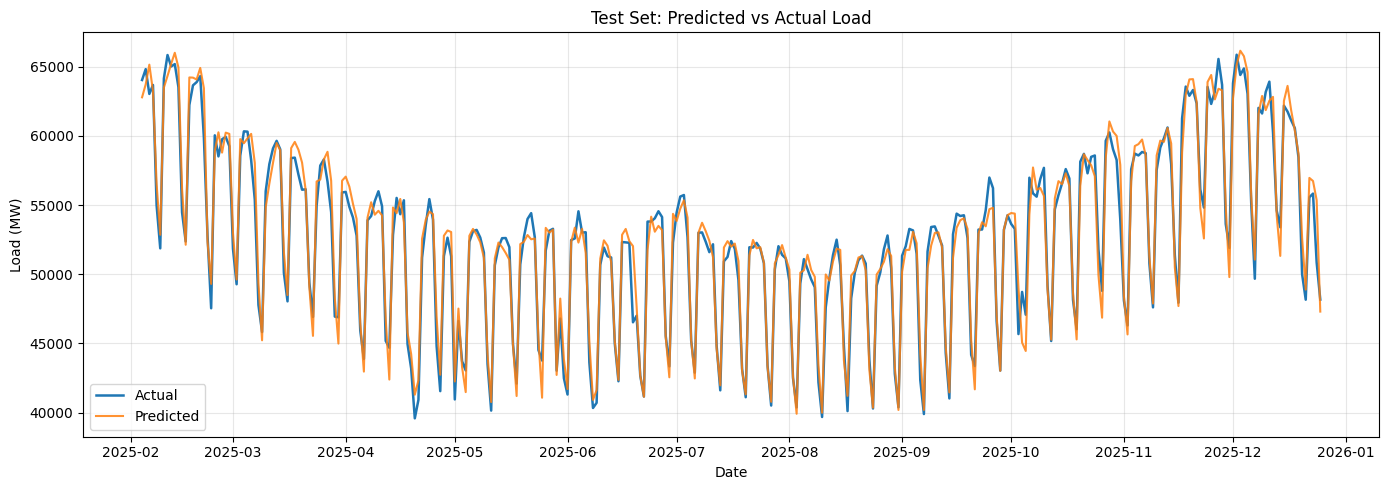

In [5]:
from utils.visualize_model_performance import evaluate_and_plot_model_torch

if TEST:
    if not os.path.exists(BEST_MODEL_PATH):
        raise FileNotFoundError(
            f"Saved model not found at {BEST_MODEL_PATH}. "
            "Run training first with TRAINING=True to create a compatible checkpoint."
        )

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
    checkpoint_target_scaled = False

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model_state_dict = checkpoint["model_state_dict"]
        checkpoint_target_scaled = bool(checkpoint.get("target_scaled", False))
        ckpt_target_mean = float(checkpoint.get("target_mean", target_mean))
        ckpt_target_std = float(checkpoint.get("target_std", target_std))
    else:
        # Backward compatibility for legacy checkpoints saved as raw state_dict.
        model_state_dict = checkpoint
        ckpt_target_mean = target_mean
        ckpt_target_std = target_std

    try:
        model.load_state_dict(model_state_dict)
    except RuntimeError as exc:
        raise RuntimeError(
            "Checkpoint is incompatible with current model/features. "
            "Please retrain with TRAINING=True so a new checkpoint is saved. "
            f"Original error: {exc}"
        ) from exc

    model = model.to(DEVICE)

    if checkpoint_target_scaled:
        eval_target_mean = ckpt_target_mean
        eval_target_std = ckpt_target_std
        print("Using target inverse scaling from checkpoint metadata.")
    else:
        eval_target_mean = None
        eval_target_std = None
        print("Legacy checkpoint detected (no target scaling metadata). Evaluating without inverse scaling.")

    test_predictions_df = evaluate_and_plot_model_torch(
        model=model,
        test_loader=test_loader,
        y_test=y_test if checkpoint_target_scaled else y_test_raw,
        test_df=test_df,
        device=DEVICE,
        window_size=WINDOW_SIZE,
        target_mean=eval_target_mean,
        target_std=eval_target_std,
    )